## Problem Statement

The goal of this project is to predict whether a student will be placed based on 
their academic performance, skills, and extracurricular profile.

**Dataset:** 215 students with features including CGPA, SSC/HSC marks, internships, 
aptitude test scores, soft skills rating, and extracurricular activities.

**Target Variable:** PlacementStatus (Placed / Not Placed)

**Algorithm Used:** Random Forest Classifier — chosen for its robustness on small 
tabular datasets, ability to handle mixed feature types, and built-in feature importance.

**Success Criterion:** Prediction accuracy > 60%

In [138]:
import pandas as pd
from sklearn.model_selection import train_test_split   
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import OrdinalEncoder
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer


In [139]:
placement_data = pd.read_csv('data/Placement.csv')
placement_data.drop('StudentID', axis=1, inplace=True)



/tmp/ipykernel_69561/2979046168.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax=sns.countplot(x='PlacementStatus', data=placement_data, palette=[ '#F44336','#4CAF50'], width=0.5)


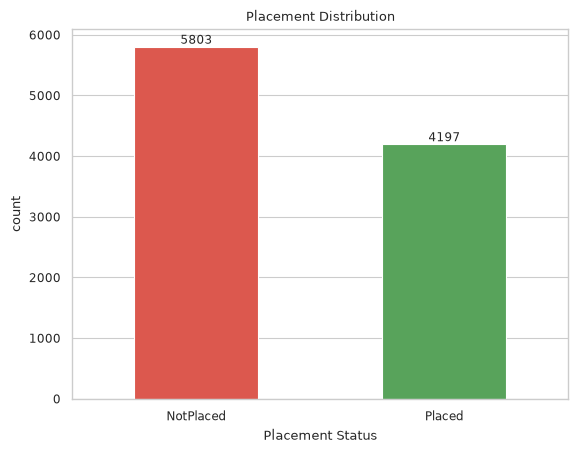

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

ax=sns.countplot(x='PlacementStatus', data=placement_data, palette=[ '#F44336','#4CAF50'], width=0.5)
plt.xlabel('Placement Status')
plt.title('Placement Distribution')

for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width()/2, p.get_height()+2), ha='center', va='bottom', size=8.5)


<Axes: xlabel='CGPA', ylabel='AptitudeTestScore'>

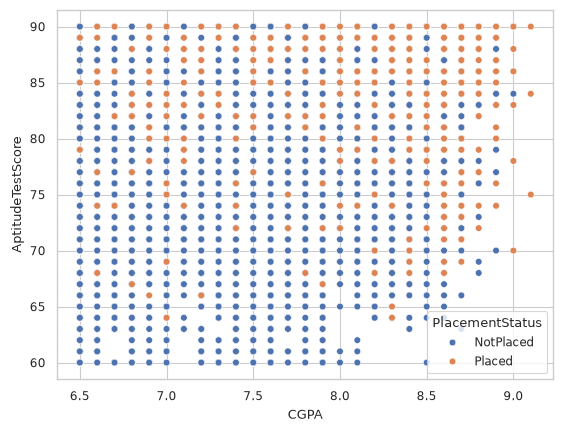

In [141]:
sns.scatterplot(x='CGPA', y='AptitudeTestScore', hue='PlacementStatus', data=placement_data)


<Axes: xlabel='PlacementTraining', ylabel='count'>

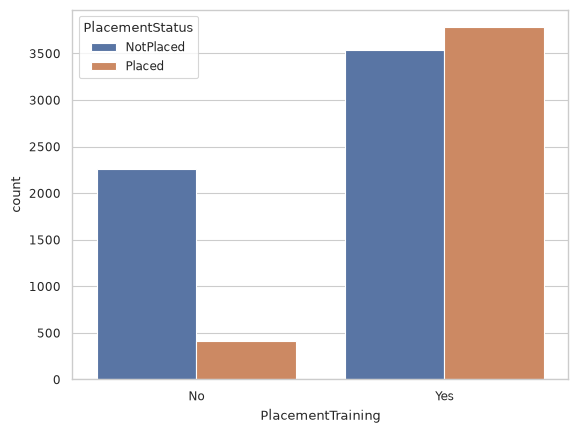

In [142]:
sns.countplot( x='PlacementTraining',hue='PlacementStatus' ,data=placement_data)

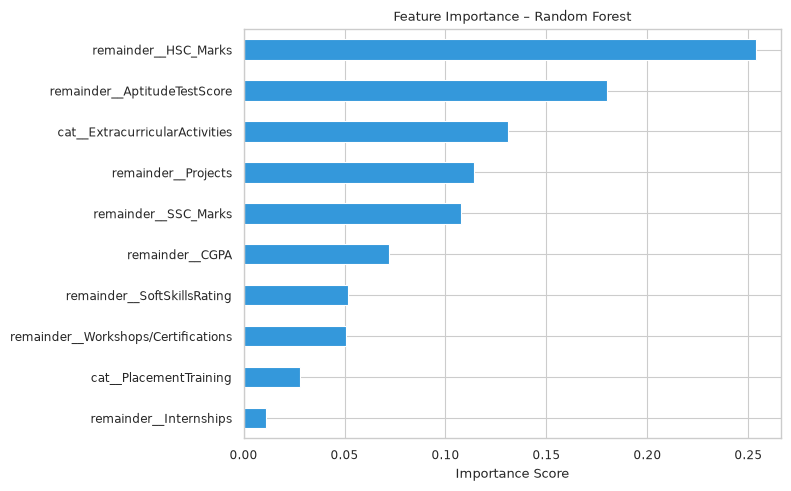

In [143]:
feature_names = model.named_steps['preprocessor'].get_feature_names_out()
importances = model.named_steps['model'].feature_importances_

feat_imp = pd.Series(importances, index=feature_names).sort_values(ascending=True)

feat_imp.plot(kind='barh', figsize=(8, 5), color='#3498db', edgecolor='white')
plt.title('Feature Importance – Random Forest')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

In [144]:
y = placement_data['PlacementStatus']
X = placement_data.drop(columns=['PlacementStatus'])
X_train, X_valid, y_train, y_valid = train_test_split(
    X, y, random_state=0
)


In [145]:
cat_col= X.select_dtypes(include=['str']).columns
cat_transformer = Pipeline(steps=[
    ('ordinal', OrdinalEncoder())
])

preprocessor = ColumnTransformer(
    transformers=[
        ('cat', cat_transformer,cat_col)
    ],remainder='passthrough')  

model=Pipeline(steps=[('preprocessor', preprocessor),
                      ('model', RandomForestClassifier(n_estimators=200, max_depth=8, min_samples_leaf=3, random_state=0))]) 

model.fit(X_train, y_train)

predictions = model.predict(X_valid)
score=model.score(X_valid, y_valid)
print("Accuracy of the model is: ", score*100, "%")



Accuracy of the model is:  78.96 %
